In [4]:
# load the module
%load_ext autoreload
%autoreload 2

import sys 
sys.path.append("../Qtensor")
sys.path.append("../Qtensor/qtree_git")
sys.path.append("../Qtensor/qtree_git/qtree")
sys.path.append("../classical_benchmarks")
sys.path.append("../Experiments/SetCover")
sys.path.append("../../..")
sys.path.append("..")

import json
import copy
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import Generating_Problems as Generator
from gurobi_optimods.qubo import solve_qubo
import qubovert as qv
from qubovert.problems import SetCover as qv_SetCover


In [1]:
ns = range(100)
run = 1

In [2]:
def gurobi_solver(set, subsets):
    problem = qv_SetCover(set, subsets)
    Q = problem.to_qubo()
    size = problem.num_binary_variables
    matrix = np.zeros((size, size))
    for key, value in Q.items():
        if len(key)==0:
            pass
        elif len(key) == 1:
            matrix[key[0], key[0]] = value
        else:
            matrix[key[0], key[1]] = value

    result = solve_qubo(matrix)
    set_size = 0
    for i in range(len(subsets)):
        set_size += result.solution[i]
        
    return set_size

In [17]:
set_sizes = []
shrinking_sizes = []
greedy_sizes = []
num_examples = 0

for n in ns: 
    with open(f'../data/results_node{n}_run_{run}.json') as f:
        data = json.load(f)
    
    for dic in data:
        set = dic["Set"]
        subsets = dic["Subsets"]
        shrinking_solution = dic["shrinking_solution"]
        problem = Generator.SetCover(set, subsets, A=2, B=1)   
        valid, rest_size = problem.solution_check(shrinking_solution)
        
        #if valid:
        optimal_size = gurobi_solver(set, subsets)
        size = len(dic["Set"])
        size_shrinking = dic["shrinking_size"]
        size_greedy = dic['greedy_size']

        corrected_shrinking_size = size_shrinking + rest_size

        set_sizes.append(size)
        #for original size:
        #shrinking_sizes.append(size_shrinking/optimal_size)

        #for corrected size:
        shrinking_sizes.append(corrected_shrinking_size/optimal_size)

        greedy_sizes.append(size_greedy/optimal_size)
        num_examples +=1

New QUBO solution found with objective 0.0
New QUBO solution found with objective -53.0
New QUBO solution found with objective -63.0
New QUBO solution found with objective -64.0
New QUBO solution found with objective 0.0
New QUBO solution found with objective -54.0
New QUBO solution found with objective -56.0
New QUBO solution found with objective -61.0
New QUBO solution found with objective -70.0
New QUBO solution found with objective -71.0
New QUBO solution found with objective 0.0
New QUBO solution found with objective -56.0
New QUBO solution found with objective -64.0
New QUBO solution found with objective -66.0
New QUBO solution found with objective -68.0
New QUBO solution found with objective -69.0
New QUBO solution found with objective -70.0
New QUBO solution found with objective 0.0
New QUBO solution found with objective -54.0
New QUBO solution found with objective -56.0
New QUBO solution found with objective -61.0
New QUBO solution found with objective -70.0
New QUBO solution 

In [18]:
num_examples

5050

In [19]:
size_to_shrinking_values = defaultdict(list)
size_to_greedy_values = defaultdict(list)

# Fill the dictionary with values corresponding to each size
for size, shrinking_value, greedy_value in zip(set_sizes, shrinking_sizes, greedy_sizes):
    size_to_shrinking_values[size].append(shrinking_value)
    size_to_greedy_values[size].append(greedy_value)


# Initialize the lists for unique sizes and mean values
unique_sizes = []
mean_values_shrinking = []
mean_values_greedy = []

# Compute mean values for each unique size
for size in size_to_shrinking_values:
    unique_sizes.append(size)
    mean_values_shrinking.append(np.mean(size_to_shrinking_values[size]))

# Compute mean values for each unique size
for size in size_to_greedy_values:
    mean_values_greedy.append(np.mean(size_to_greedy_values[size]))

# for size in unique_sizes:
#     print("\nsize")
#     print('shrinking', len(size_to_shrinking_values[size]))
#     print('greedy', len(size_to_greedy_values[size]))



list_to_sort_by = unique_sizes
zipped_lists = zip(list_to_sort_by, unique_sizes, mean_values_shrinking, mean_values_greedy)
sorted_zipped_lists = sorted(zipped_lists, key = lambda x: x[0])
_, sorted_unique_sizes, sorted_mean_values_shrinking, sorted_mean_values_greedy = zip(*sorted_zipped_lists)
sorted_unique_sizes = list(sorted_unique_sizes)
sorted_mean_values_shrinking = list(sorted_mean_values_shrinking)
sorted_mean_values_greedy = list(sorted_mean_values_greedy)


### All valid solutions

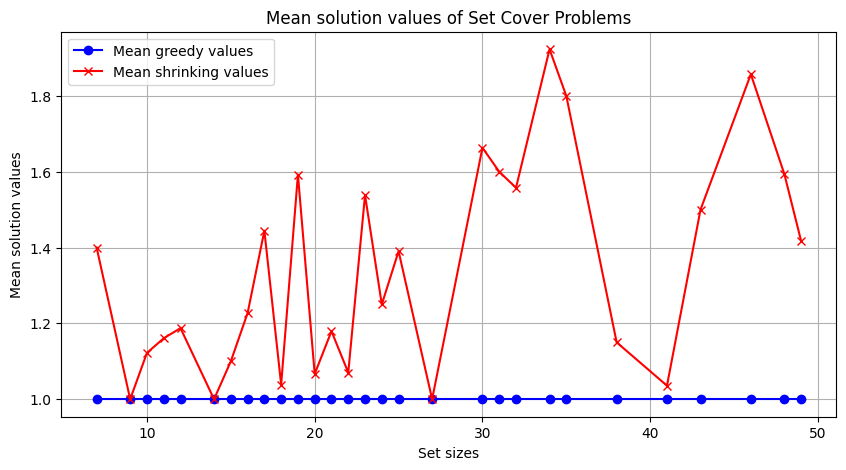

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(sorted_unique_sizes, sorted_mean_values_greedy, marker='o', linestyle='-', color='b', label='Mean greedy values')
plt.plot(sorted_unique_sizes, sorted_mean_values_shrinking, marker='x', linestyle='-', color='r', label='Mean shrinking values')


# Adding labels and title
plt.xlabel('Set sizes')
plt.ylabel('Mean solution values')
plt.title('Mean solution values of Set Cover Problems')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

### All corrected solutions

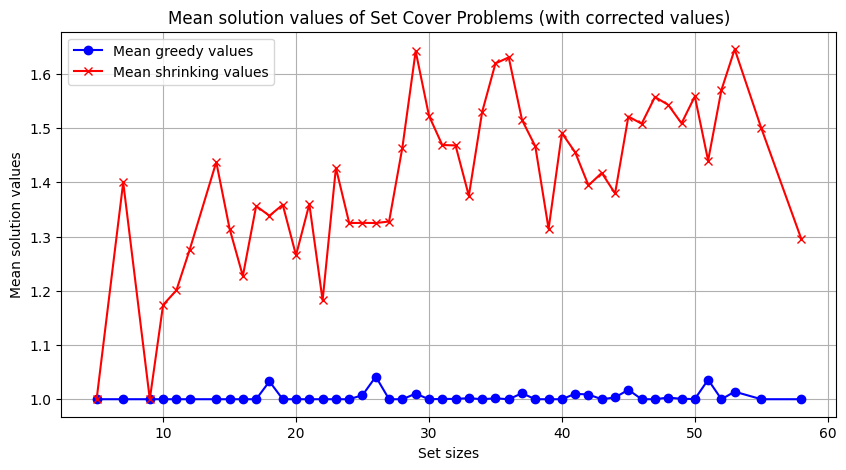

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(sorted_unique_sizes, sorted_mean_values_greedy, marker='o', linestyle='-', color='b', label='Mean greedy values')
plt.plot(sorted_unique_sizes, sorted_mean_values_shrinking, marker='x', linestyle='-', color='r', label='Mean shrinking values')


# Adding labels and title
plt.xlabel('Set sizes')
plt.ylabel('Mean solution values')
plt.title('Mean solution values of Set Cover Problems (with corrected values)')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()